In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report , roc_auc_score , confusion_matrix , roc_curve , auc
from imblearn.over_sampling import SMOTE
from geopy.distance import geodesic
import joblib

ModuleNotFoundError: No module named 'pandas'

In [ ]:
df = pd.read_csv("dataset.csv")

In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0.0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0.0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0.0


In [ ]:
df.shape

(399327, 23)

In [ ]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399327 entries, 0 to 399326
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             399327 non-null  int64  
 1   trans_date_trans_time  399327 non-null  object 
 2   cc_num                 399327 non-null  int64  
 3   merchant               399327 non-null  object 
 4   category               399327 non-null  object 
 5   amt                    399327 non-null  float64
 6   first                  399327 non-null  object 
 7   last                   399327 non-null  object 
 8   gender                 399327 non-null  object 
 9   street                 399327 non-null  object 
 10  city                   399327 non-null  object 
 11  state                  399327 non-null  object 
 12  zip                    399327 non-null  int64  
 13  lat                    399327 non-null  float64
 14  long                   399327 non-nu

In [ ]:
df[['is_fraud']].value_counts()

,count
is_fraud,
0.0,396678
1.0,2648


In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month

In [ ]:
drop_columns = ['Unnamed: 0','trans_date_trans_time','first','last','street','city','state','zip','dob','job','trans_num']
df = df.drop(columns=drop_columns)

In [ ]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month
0,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,F,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0.0,0,1,1
1,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,F,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0.0,0,1,1
2,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,M,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0.0,0,1,1
3,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,M,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0.0,0,1,1
4,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,M,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0.0,0,1,1


In [ ]:
df.shape

(399327, 15)

In [ ]:
cat_col = ['merchant','category','gender']
encoder = {}
for col in cat_col:
  encoder[col] = LabelEncoder()
  df[col] = encoder[col].fit_transform(df[col])

In [ ]:
df.shape

(399327, 15)

In [ ]:
df = df.dropna(subset=['lat','long','merch_lat','merch_long'])

In [ ]:
df.shape

(399326, 15)

In [ ]:
def haversine(lat1,lon1,lat2,lon2):
  return np.array([geodesic((a,b),(c,d)).km for a,b,c,d in zip(lat1,lon1,lat2,lon2)])

df['distance'] = haversine(df['lat'],df['long'],df['merch_lat'],df['merch_long'])

/tmp/ipykernel_1350/1520272476.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['distance'] = haversine(df['lat'],df['long'],df['merch_lat'],df['merch_long'])


In [ ]:
df.head()

,cc_num,merchant,category,amt,gender,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,hour,day,month,distance
0,2703186189652095,514,8,4.97,0,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315,0.0,0,1,1,78.773821
1,630423337322,241,4,107.23,0,48.8878,-118.2105,149,1325376044,49.159047,-118.186462,0.0,0,1,1,30.216618
2,38859492057661,390,0,220.11,1,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481,0.0,0,1,1,108.102912
3,3534093764340240,360,2,45.00,1,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071,0.0,0,1,1,95.685115
4,375534208663984,297,9,41.96,1,38.4207,-79.4629,99,1325376186,38.674999,-78.632459,0.0,0,1,1,77.702395


In [ ]:
features = ['merchant','category','amt','cc_num','hour','day','month','gender','distance']
X= df[features]
Y= df['is_fraud']

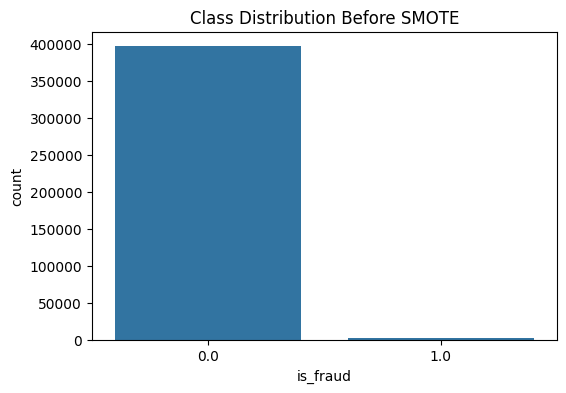

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_fraud',data=df)
plt.title("Class Distribution Before SMOTE")
plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_resample ,Y_resample = smote.fit_resample(X,Y)

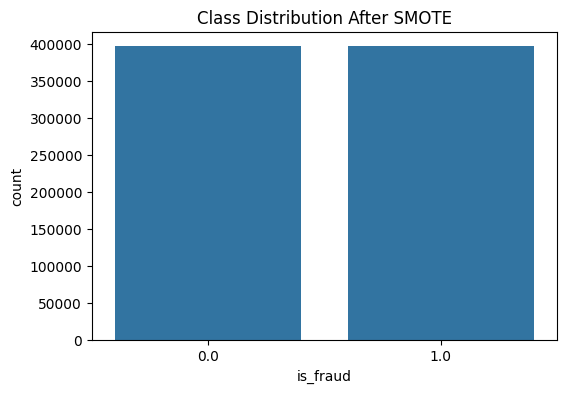

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=Y_resample)
plt.title("Class Distribution After SMOTE")
plt.show()

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X_resample,Y_resample,test_size=0.2,random_state=42)

In [ ]:
lgb_model = lgb.LGBMClassifier(
    boosting_type = 'gbdt',
    objective = 'binary',
    metrics = 'auc',
    is_unbalanced = True,
    learning_rate = 0.02,
    num_leaves = 31,
    max_dept=1,
    n_estimators=200
)
lgb_model.fit(X_train,Y_train)

[LightGBM] [Warning] Unknown parameter: max_dept
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: max_dept
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Info] Number of positive: 317317, number of negative: 317367
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019650 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1098
[LightGBM] [Info] Number of data points in the train set: 634684, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499961 -> initscore=-0.000158
[LightGBM] [Info] Start training from score -0.000158


LGBMClassifier(is_unbalanced=True, learning_rate=0.02, max_dept=1,
               metrics='auc', n_estimators=200, objective='binary')

In [ ]:
Y_pred = lgb_model.predict(X_test)

[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: max_dept


In [ ]:
print("Classification_Report:\n" , classification_report(Y_test,Y_pred))
print("Roc AUC Score: " , roc_auc_score(Y_test,Y_pred))

Classification_Report:
               precision    recall  f1-score   support

         0.0       0.91      0.97      0.94     79311
         1.0       0.97      0.91      0.94     79361

    accuracy                           0.94    158672
   macro avg       0.94      0.94      0.94    158672
weighted avg       0.94      0.94      0.94    158672

Roc AUC Score:  0.9371944764259631


<function matplotlib.pyplot.show(close=None, block=None)>

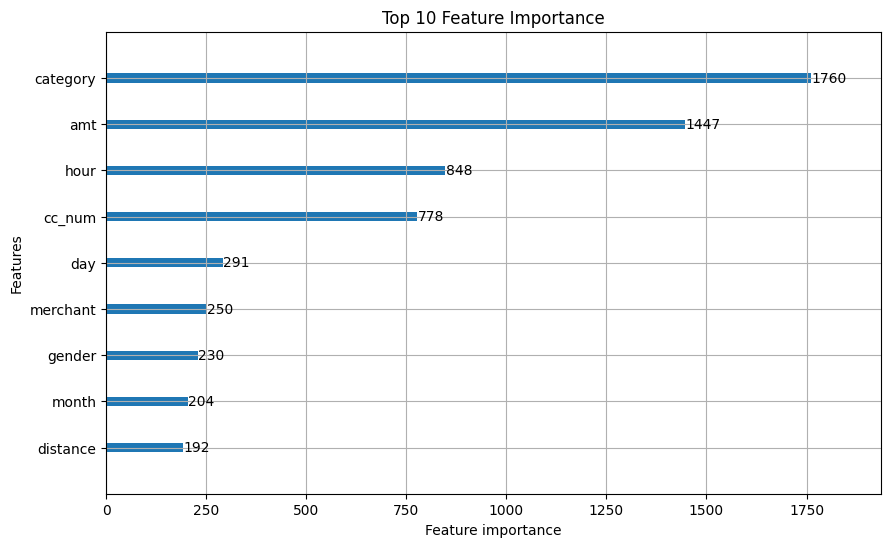

In [ ]:
lgb.plot_importance(lgb_model,max_num_features=10,importance_type='split',figsize=(10,6))
plt.title("Top 10 Feature Importance")
plt.show

In [ ]:
fpr , tpr , thresholds = roc_curve(Y_test,lgb_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr ,tpr)

[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: max_dept


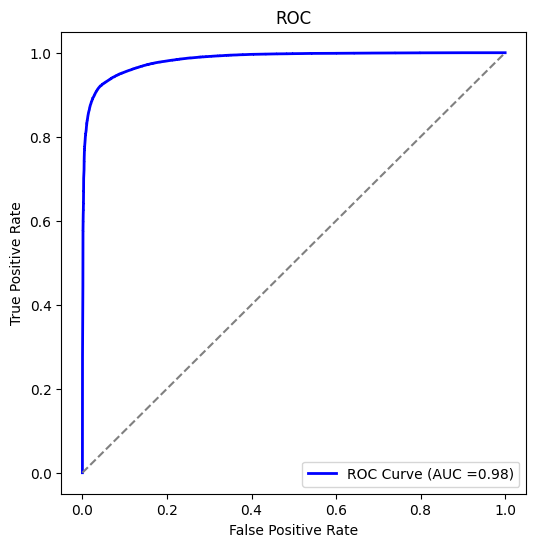

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,color='blue',lw=2,label=f'ROC Curve (AUC ={roc_auc:.2f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.title("ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

In [ ]:
joblib.dump(lgb_model,"fraud_detection_model.jb")
joblib.dump(encoder,'label_encoder.jb')

['label_encoder.jb']